# Define model - three layer FCN (MLP)

In [12]:
import torch.nn as nn
import torch.nn.functional as F
class MLP(nn.Module):
    def __init__(self, n_states,n_actions,hidden_dim=128):
        #MLP
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(n_states, hidden_dim) # input layer
        self.fc2 = nn.Linear(hidden_dim,hidden_dim) # hidden
        self.fc3 = nn.Linear(hidden_dim, n_actions) # output
        
    def forward(self, x):
        # activation function
        x = F.relu(self.fc1(x)) 
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Experience replay

In [13]:
from collections import deque
import random
class ReplayBuffer(object):

    def __init__(self, capacity: int) -> None:
        self.capacity = capacity
        self.buffer = deque(maxlen=self.capacity)

    def push(self,transitions):
        #store transition in experience buffer
        self.buffer.append(transitions)

    def sample(self, batch_size: int, sequential: bool = False):
        # batch size > capasity of experience replay: take experience replar's capasity
        if batch_size > len(self.buffer): 
            batch_size = len(self.buffer)
        # Sequence sampling
        if sequential: 
            rand = random.randint(0, len(self.buffer) - batch_size)
            batch = [self.buffer[i] for i in range(rand, rand + batch_size)]
            return zip(*batch)
        # random sampling
        else: 
            batch = random.sample(self.buffer, batch_size)
            return zip(*batch)
        
    def clear(self):
        #clear experience buffer
        self.buffer.clear()

    def __len__(self):
        #return current stored
        return len(self.buffer)

# DQN algorithm

In [14]:
import torch
import torch.optim as optim
import math
import numpy as np
class DQN:

    def __init__(self,model,memory,cfg):

        self.n_actions = cfg['n_actions']  
        self.device = torch.device(cfg['device']) 
        self.gamma = cfg['gamma'] # discount factor of reward

        # relevant parameters about e-greedy strategy
        self.sample_count = 0  # count of eplison's decay
        self.epsilon = cfg['epsilon_start']
        self.sample_count = 0  
        self.epsilon_start = cfg['epsilon_start']
        self.epsilon_end = cfg['epsilon_end']
        self.epsilon_decay = cfg['epsilon_decay']

        self.batch_size = cfg['batch_size']
        self.policy_net = model.to(self.device)
        self.target_net = model.to(self.device)

        # copy parameters to target network
        for target_param, param in zip(self.target_net.parameters(),self.policy_net.parameters()): 
            target_param.data.copy_(param.data)
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg['lr']) # optimizer
        self.memory = memory # experience replay

    

    # sampling action
    def sample_action(self, state):

        self.sample_count += 1
        # epsilon exponential decay
        self.epsilon = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
            math.exp(-1. * self.sample_count / self.epsilon_decay) 
        
        if random.random() > self.epsilon:
            with torch.no_grad(): # close gradient calculation
                state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
                q_values = self.policy_net(state)
                action = q_values.max(1)[1].item() # choose action corresponding to the maximum q value
        else:
            action = random.randrange(self.n_actions)
        return action
    @torch.no_grad() # no gradient calculation, this decorator = "with torch.no_grad()"



    # action prediction
    def predict_action(self, state):
    
        state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
        q_values = self.policy_net(state)
        action = q_values.max(1)[1].item() # choose action corresponding to the maximum q value
        return action
    

    def update(self):
        # when a batch is not satisfied in experience replay, the strategy is not updated.
        # that is, there are not enough samples for a model update
        if len(self.memory) < self.batch_size:
            return
        
        # randomly sample a batch of transitions from experience
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = self.memory.sample(
            self.batch_size)
        
        # transform data into tensor
        state_batch = torch.tensor(np.array(state_batch), device=self.device, dtype=torch.float)
        action_batch = torch.tensor(action_batch, device=self.device).unsqueeze(1)  
        reward_batch = torch.tensor(reward_batch, device=self.device, dtype=torch.float)  
        next_state_batch = torch.tensor(np.array(next_state_batch), device=self.device, dtype=torch.float)
        done_batch = torch.tensor(np.float32(done_batch), device=self.device)

        # calculate Q(s_t, a) corresponding to the current state (s_t, a)
        q_values = self.policy_net(state_batch).gather(dim=1, index=action_batch) 

        # caluculate Q value corresponding to the state (s_t, a) at the next time
        # detach: stop gradient propagation. Because the parameters of the target network are usually updated in a fixed way.
        next_q_values = self.target_net(next_state_batch).max(1)[0].detach() 

        # calculate the expected Q value, for the terminal state: done_batch[0]=1, so expected_q_value = reward
        expected_q_values = reward_batch + self.gamma * next_q_values * (1-done_batch)

        # calculate mean square error (MSE)
        loss = nn.MSELoss()(q_values, expected_q_values.unsqueeze(1))

        self.optimizer.zero_grad() # clear the gradeint to 0. Otherwise, new gradient will be added to previous gradient.
        loss.backward() # back propagation. each parameter is tored in corresponding tensor's ".grad" attribute.


        for param in self.policy_net.parameters():  
            param.grad.data.clamp_(-1, 1) # limit the gradient tensor's value in [-1, 1]
        self.optimizer.step() # update parameters by gradient

# Define training

In [15]:
def train(cfg, env, agent):

    #print("Training started")
    rewards = []  # record all the episodes' reward
    steps = []

    for i_ep in range(cfg['train_eps']):
        ep_reward = 0  # record reward within an episode
        ep_step = 0
        state = env.reset()  # reset

        for _ in range(cfg['ep_max_steps']):
            ep_step += 1
            action = agent.sample_action(state)  # choose an action
            next_state, reward, done, _ = env.step(action)  # update environment, return transition
            agent.memory.push((state, action, reward,next_state, done))  # save transition
            state = next_state  # update next state
            agent.update()  # update agent
            ep_reward += reward  # accumulate reward
            if done:
                break

        # update target network
        if (i_ep + 1) % cfg['target_update'] == 0: 
            agent.target_net.load_state_dict(agent.policy_net.state_dict())

        steps.append(ep_step)
        rewards.append(ep_reward)

        if (i_ep + 1) % 10 == 0:
            print(f"episode：{i_ep+1}/{cfg['train_eps']}，reward：{ep_reward:.2f}，Epislon：{agent.epsilon:.3f}")

    print("Training finished！")
    env.close()
    return {'rewards':rewards}



def test(cfg, env, agent):
    print("Testing started")
    rewards = []  # record all the episodes' reward
    steps = []

    for i_ep in range(cfg['test_eps']):
        ep_reward = 0  # record reward within an episode
        ep_step = 0
        state = env.reset()  # reset

        for _ in range(cfg['ep_max_steps']):
            ep_step+=1
            action = agent.predict_action(state)  # choose an action
            next_state, reward, done, _ = env.step(action)  # update environment, return transition
            state = next_state  # update next state
            ep_reward += reward  # accumulate reward
            if done:
                break

        steps.append(ep_step)
        rewards.append(ep_reward)
        print(f"episode：{i_ep+1}/{cfg['test_eps']}，reward：{ep_reward:.2f}")

    print("Testing finished")
    env.close()
    return {'rewards':rewards}

# Define environment

In [16]:
import gym
import os
def all_seed(env,seed = 1):
   
    env.seed(seed) # env config
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed) # config for CPU
    torch.cuda.manual_seed(seed) # config for GPU
    os.environ['PYTHONHASHSEED'] = str(seed) # config for python scripts
    # config for cudnn
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False


def env_agent_config(cfg):

    env = gym.make(cfg['env_name']) # build environment
    if cfg['seed'] !=0:
        all_seed(env,seed=cfg['seed'])

    n_states = env.observation_space.shape[0]
    n_actions = env.action_space.n
    print(f"observation space's dimension：{n_states}，action space's dimension：{n_actions}")
    cfg.update({"n_states":n_states,"n_actions":n_actions}) # update 'n_states' and 'n_actions' to cfg parameters

    #build model
    model = MLP(n_states, n_actions, hidden_dim = cfg['hidden_dim'])
    memory = ReplayBuffer(cfg['memory_capacity'])
    agent = DQN(model,memory,cfg)
    return env, agent

# Parameter settings

In [17]:
import argparse
import matplotlib.pyplot as plt
import seaborn as sns

def get_args():

    # parameters
    parser = argparse.ArgumentParser(description="hyperparameters")      
    parser.add_argument('--algo_name',default='DQN',type=str,help="name of algorithm")
    parser.add_argument('--env_name',default='CartPole-v0',type=str,help="name of environment")
    parser.add_argument('--train_eps',default=200,type=int,help="episodes of training")
    parser.add_argument('--test_eps',default=20,type=int,help="episodes of testing")
    parser.add_argument('--ep_max_steps',default = 100000,type=int,help="steps per episode, much larger value can simulate infinite steps")
    parser.add_argument('--gamma',default=0.95,type=float,help="discounted factor")
    parser.add_argument('--epsilon_start',default=0.95,type=float,help="initial value of epsilon")
    parser.add_argument('--epsilon_end',default=0.01,type=float,help="final value of epsilon")
    parser.add_argument('--epsilon_decay',default=500,type=int,help="decay rate of epsilon, the higher value, the slower decay")
    parser.add_argument('--lr',default=0.0001,type=float,help="learning rate")
    parser.add_argument('--memory_capacity',default=100000,type=int,help="memory capacity")
    parser.add_argument('--batch_size',default=64,type=int)
    parser.add_argument('--target_update',default=4,type=int)
    parser.add_argument('--hidden_dim',default=256,type=int)
    parser.add_argument('--device',default='cpu',type=str,help="cpu or cuda") 
    parser.add_argument('--seed',default=10,type=int,help="seed")   

    args = parser.parse_args([]) # []: blank list; prser will use the default value, no need to get the actual parameters from the command line
    args = {**vars(args)}  # transfer to dict   
    
    print("Hyper parameters")
    print(''.join(['=']*80))
    tplt = "{:^20}\t{:^20}\t{:^20}"
    print(tplt.format("Name", "Value", "Type"))

    for k,v in args.items():
        print(tplt.format(k,v,str(type(v))))   

    print(''.join(['=']*80))      
    return args


#smooth data
def smooth(data, weight=0.9):  
    
    last = data[0] 
    smoothed = [] # store data after smoothing

    for point in data:
        smoothed_val = last * weight + (1 - weight) * point  # calculating smoothing value
        smoothed.append(smoothed_val)                    
        last = smoothed_val                                
    return smoothed


def plot_rewards(rewards, cfg, tag='train'):
  
    sns.set()
    plt.figure()  # build figure instance to print more figures at the same time
    plt.title(f"{tag}ing curve on {cfg['device']} of {cfg['algo_name']} for {cfg['env_name']}")
    plt.xlabel('epsiodes')
    plt.plot(rewards, label='rewards')
    plt.plot(smooth(rewards), label='smoothed')
    plt.legend()
    plt.show()

# Real training

Hyper parameters
        Name        	       Value        	        Type        
     algo_name      	        DQN         	   <class 'str'>    
      env_name      	    CartPole-v0     	   <class 'str'>    
     train_eps      	        200         	   <class 'int'>    
      test_eps      	         20         	   <class 'int'>    
    ep_max_steps    	       100000       	   <class 'int'>    
       gamma        	        0.95        	  <class 'float'>   
   epsilon_start    	        0.95        	  <class 'float'>   
    epsilon_end     	        0.01        	  <class 'float'>   
   epsilon_decay    	        500         	   <class 'int'>    
         lr         	       0.0001       	  <class 'float'>   
  memory_capacity   	       100000       	   <class 'int'>    
     batch_size     	         64         	   <class 'int'>    
   target_update    	         4          	   <class 'int'>    
     hidden_dim     	        256         	   <class 'int'>    
       device       	        cpu      

/Users/jingyul/anaconda3/lib/python3.11/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/jingyul/anaconda3/lib/python3.11/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/jingyul/anaconda3/lib/python3.11/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/jingyul/anaconda3/lib/python3.11/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be re

episode：30/200，reward：15.00，Epislon：0.379
episode：40/200，reward：11.00，Epislon：0.310
episode：50/200，reward：12.00，Epislon：0.246
episode：60/200，reward：40.00，Epislon：0.143
episode：70/200，reward：74.00，Epislon：0.041
episode：80/200，reward：200.00，Epislon：0.011
episode：90/200，reward：200.00，Epislon：0.010
episode：100/200，reward：200.00，Epislon：0.010
episode：110/200，reward：200.00，Epislon：0.010
episode：120/200，reward：200.00，Epislon：0.010
episode：130/200，reward：200.00，Epislon：0.010
episode：140/200，reward：200.00，Epislon：0.010
episode：150/200，reward：200.00，Epislon：0.010
episode：160/200，reward：200.00，Epislon：0.010
episode：170/200，reward：200.00，Epislon：0.010
episode：180/200，reward：200.00，Epislon：0.010
episode：190/200，reward：200.00，Epislon：0.010
episode：200/200，reward：200.00，Epislon：0.010
Training finished！


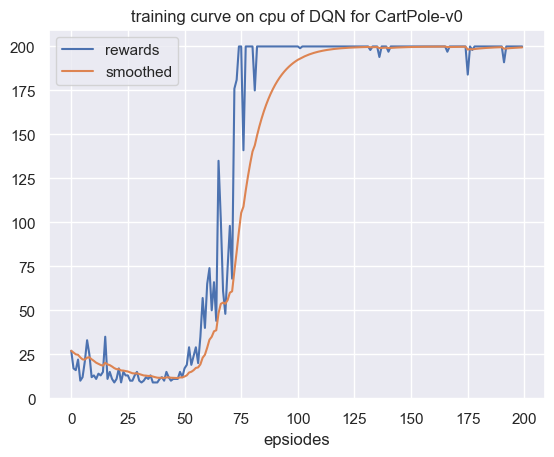

Testing started
episode：1/20，reward：200.00
episode：2/20，reward：199.00
episode：3/20，reward：200.00
episode：4/20，reward：200.00
episode：5/20，reward：200.00
episode：6/20，reward：200.00
episode：7/20，reward：200.00
episode：8/20，reward：200.00
episode：9/20，reward：200.00
episode：10/20，reward：200.00
episode：11/20，reward：200.00
episode：12/20，reward：200.00
episode：13/20，reward：200.00
episode：14/20，reward：200.00
episode：15/20，reward：200.00
episode：16/20，reward：200.00
episode：17/20，reward：197.00
episode：18/20，reward：200.00
episode：19/20，reward：200.00
episode：20/20，reward：200.00
Testing finished


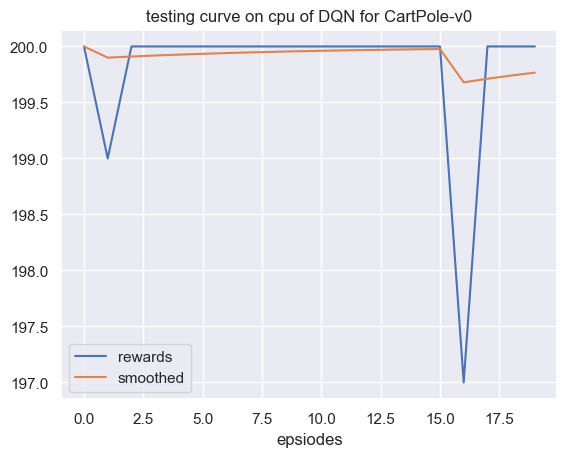

In [18]:
# get parameters
cfg = get_args() 
# training
env, agent = env_agent_config(cfg)
res_dic = train(cfg, env, agent)
 
plot_rewards(res_dic['rewards'], cfg, tag="train")  
# testing
res_dic = test(cfg, env, agent)
plot_rewards(res_dic['rewards'], cfg, tag="test") 